## Predicting Future Product Demand at the Regional-Product Level

### ABOUT THE DATASET

This dataset contains order-level sales transactions from a US-based retailer selling Furniture, Office Supplies, and Technology products, covering January 2015 to December 2018. 

Each row represents one product sold as part of a customer order, along with the customer's shipping location (city, state, and region), product category, and sale amount. The dataset does not include physical store locations, geography here reflects where orders were shipped, not individual retail branches, so this analysis treats Region and State as the geographic unit of demand rather than individual stores. Hence changing the analysis focus from store level to regional level.


### RESEARCH QUESTIONS (RQ)
1. Which states and products (by category) contribute the most to overall sales?
2. What factors have the greatest influence on product demand across different regions and product categories?
3. How does product demand vary by season and time of year?
4. How does sales variability differ between Region-level and State-level data?
5. Which forecasting or machine learning approach provides the most accurate demand predictions?


### Key Variables

These are the key columns in the dataset
 - Order ID : The ID number of the order placed      
 - Order Date: The day the product was ordered    
 - Ship Date : The date/day the product would be shipped to the customer     
 - Ship Mode : The means in which the customer would receive their order       
 - Customer ID: ID number of the customer who purchased the product    
 - Customer Name: The name of the customer   
 - Segment : The category in which the product is about        
 - Country : The country the customer lives in       
 - City : The city the customer lives in          
 - State: The state the customer lives in          
 - Postal Code: The postal address of where the product is to be shipped to   
 - Region: The region of where the product is being shipped to     
 - Product ID: Product ID of the Product    
 - Category: The type of product        
 - Sub-Category: The sub-category of the product
 - Product Name: Name of the product bought  
 - Sales : Amount made from that product

In [94]:
## importing all the necessary libraries (seaborn,matplotlib,numpy and pandas) needed for this analysis

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import randint
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [95]:
## loading the superstore sales
sup_store = pd.read_csv('Superstore_sales_dataset.csv')

In [96]:
# calling the dataset
sup_store

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [97]:
## showing the number of rows and columns
sup_store.shape

(9800, 18)

The sales dataset has 18 columns and 9800 rows

In [98]:
# inspecting the dataset
sup_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### Data Cleaning Process

Under the data cleaning process, there are some inconsistencies that will be addressed like;

1. Checking of Duplicates in the dataset
2. Uniformity in Column names
3. The Datatypes
4. Getting to know some unique features in the data.

In [99]:
## checking for missing values
sup_store.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Postal code has 11 missing values.To determine whether or not it has to be dropped or replaced, will calculate for the percentage of missing values. 

In [100]:
#calculating percentage of null/ missing value in  the postal code column
#P_missing_values = (number of missing values in the columns / total number of values in the column)/100

P_postal = (sup_store['Postal Code'].isna().sum()/len(sup_store['Postal Code']))*100
P_postal

0.11224489795918367

the percentage of missing values in the Postal Code column is 0.11%. This means that approximately 0.11% of the numbers in Postal Code are missing. And since it's less than 60%, it would not be dropped.

In [101]:
sup_store.shape

(9800, 18)

In [102]:
## checking for uniformity in the column names 
## calling out all columns
sup_store.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [103]:
## Checking for the Datatypes
sup_store.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [104]:
## changing some column datatypes 

sup_store['Ship Mode'] = sup_store['Ship Mode'].astype("category")
sup_store['Segment'] = sup_store['Segment'].astype("category")
sup_store['Region'] = sup_store['Region'].astype("category")
sup_store['Category'] = sup_store['Category'].astype("category")
sup_store['Order Date'] = pd.to_datetime(sup_store['Order Date'], format='mixed', dayfirst=True)
sup_store['Ship Date'] = pd.to_datetime(sup_store['Ship Date'], format='mixed', dayfirst=True)
cat_cols = ['Ship Mode','Segment','Region','Category','Sub-Category','State','City']
sup_store[cat_cols] = sup_store[cat_cols].astype('category')


In [105]:
## Datatypes with new changes
sup_store.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode              category
Customer ID              object
Customer Name            object
Segment                category
Country                  object
City                   category
State                  category
Postal Code             float64
Region                 category
Product ID               object
Category               category
Sub-Category           category
Product Name             object
Sales                   float64
dtype: object

In [106]:
## frist 5 rows in the column
sup_store.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [107]:
## some unique features in the data
sup_store['Ship Mode'].unique()

['Second Class', 'Standard Class', 'First Class', 'Same Day']
Categories (4, object): ['First Class', 'Same Day', 'Second Class', 'Standard Class']

In [108]:
sup_store['State'].unique()

['Kentucky', 'California', 'Florida', 'North Carolina', 'Washington', ..., 'South Dakota', 'Idaho', 'North Dakota', 'Wyoming', 'West Virginia']
Length: 49
Categories (49, object): ['Alabama', 'Arizona', 'Arkansas', 'California', ..., 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

In [109]:
sup_store['Category'].unique()

['Furniture', 'Office Supplies', 'Technology']
Categories (3, object): ['Furniture', 'Office Supplies', 'Technology']

## Exploratory Data Analysis (EDA)


In [110]:
## summary statisitics 
sup_store.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,9800.000000,9800,9800,9789.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769059
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32041.223413,626.651875


In [111]:
## summary statisitics for the all column
sup_store.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,NaN,NaN,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,NaN,NaN,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
min,1.000000,NaN,2015-01-03 00:00:00,2015-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,2016-05-24 00:00:00,2016-05-27 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,2017-06-26 00:00:00,2017-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,2018-05-15 00:00:00,2018-05-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000
max,9800.000000,NaN,2018-12-30 00:00:00,2019-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99301.000000,NaN,NaN,NaN,NaN,NaN,22638.480000


In [112]:
## summary statisitics for the category datatypes column
sup_store.describe(include='category')

,Ship Mode,Segment,City,State,Region,Category,Sub-Category
count,9800,9800,9800,9800,9800,9800,9800
unique,4,3,529,49,4,3,17
top,Standard Class,Consumer,New York City,California,West,Office Supplies,Binders
freq,5859,5101,891,1946,3140,5909,1492


In [113]:
## checking for the summary statistics of the Sales Column rounding the figure to 3 decimal places
sup_store['Sales'].describe().round(3)

count     9800.000
mean       230.769
std        626.652
min          0.444
25%         17.248
50%         54.490
75%        210.605
max      22638.480
Name: Sales, dtype: float64

In [114]:
## checking for the Mode of the Sales Column
sup_store['Sales'].mode().round(3)

0    12.96
Name: Sales, dtype: float64

12.983482865034619

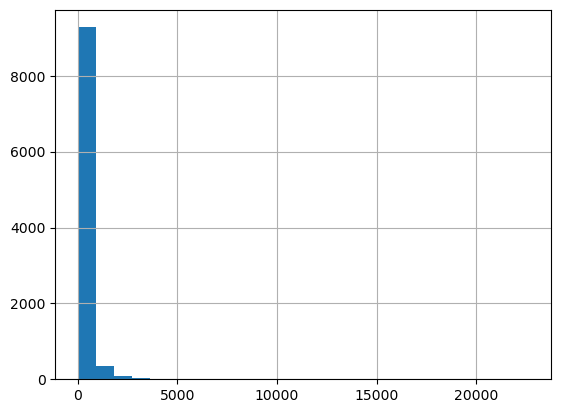

In [115]:
## checking for the distribution of the dataset using the Sales column
## note: if the outcome is: 0 ≈ it means the data is normal, if its a positive figure = the data is right-skewed,& if negative = left-skewed

sup_store['Sales'].hist(bins=25)
sup_store['Sales'].skew()

The data is right-skewed meaning it has it's mean greater than it's mode and median. And this is seen clearly from the summary statistics of the Sales column. Its Mean is 230.769, Median is 54.490 & Mode is 12.96 (the most frequently occured Sales value)

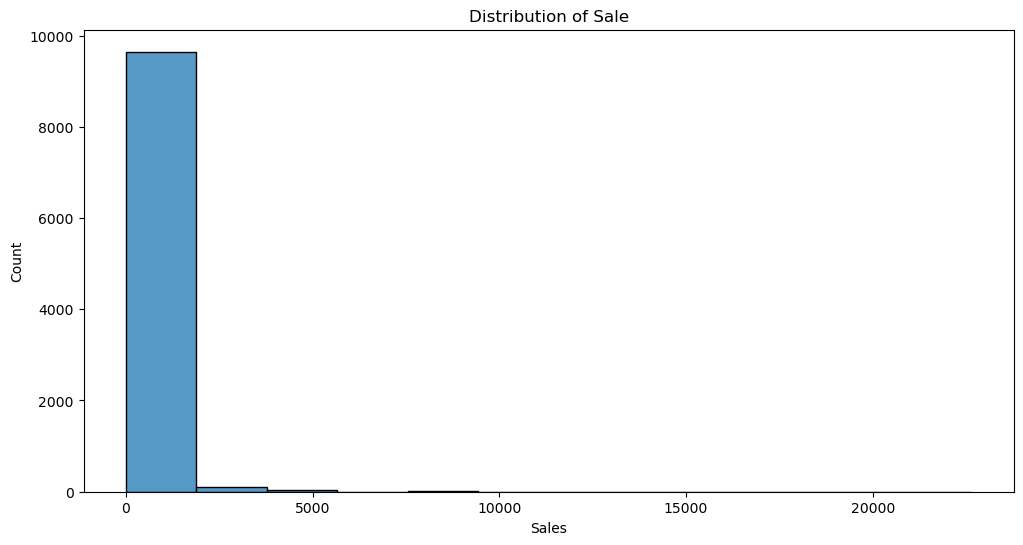

In [116]:
## checking for the distribution of the data using sale

plt.figure(figsize=(12, 6))
sns.histplot(sup_store['Sales'], bins=12)
plt.title("Distribution of Sale") 
plt.show()

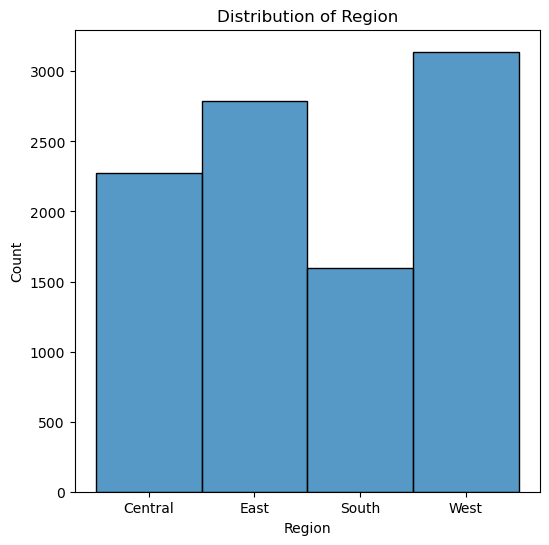

In [117]:
plt.figure(figsize=(6, 6))
sns.histplot(sup_store['Region'], bins=12)
plt.title("Distribution of Region")
plt.show()

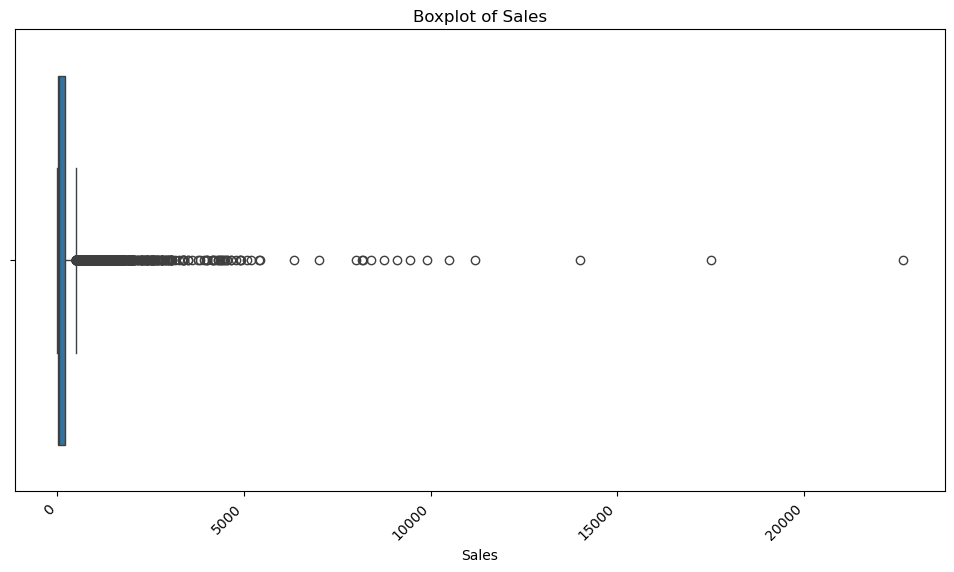

In [118]:
 ## checking for outliers, using the boxplot

plt.figure(figsize=(12, 6))
sns.boxplot(x=sup_store['Sales'])
plt.title(f'Boxplot of {'Sales'}')
plt.xlabel('Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

There are visible outliers in the data but these are needed, hence can't be removed.

## Data Visualization / Analysis


### RQ1: Which states and products contribute the most to overall sales?

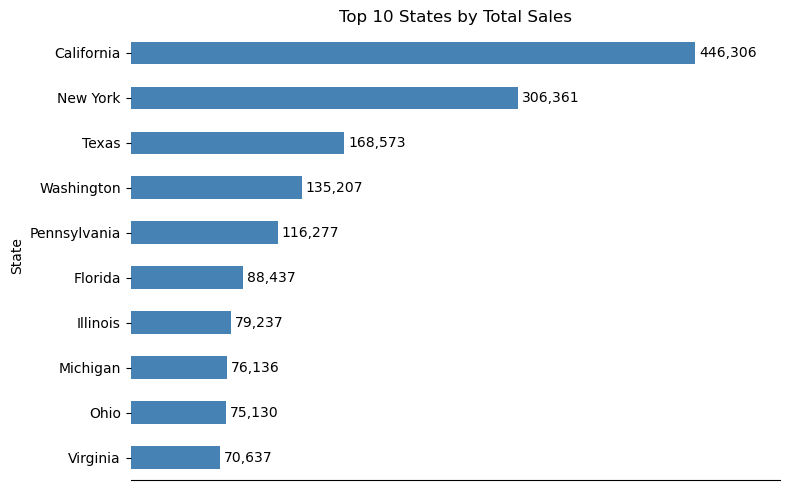

In [119]:
# RQ1: Which states and products (by category) contribute the most to overall sales?

## Since each row in the dataset is a single order, I first added up all the orders for each state to get one total sales figure per state, &
## then picked out the 10 states with the highest totals."

top_states = sup_store.groupby('State', observed=True)['Sales'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8,5))
top_states.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 States by Total Sales')
ax.bar_label(ax.containers[0], fmt=lambda x: f'{x:,.0f}', padding=3)
ax.spines[['top','right','left']].set_visible(False)
ax.set_xticks([])
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

Of the top 10 states (out of the 49 states in the dataset) with the highest sales recorded, California happened to be the state with the highest sale (ie.USD 446K), followed by the 2nd and 3rd states, New York with USD 306K & Texas with USD 169K respectively.  

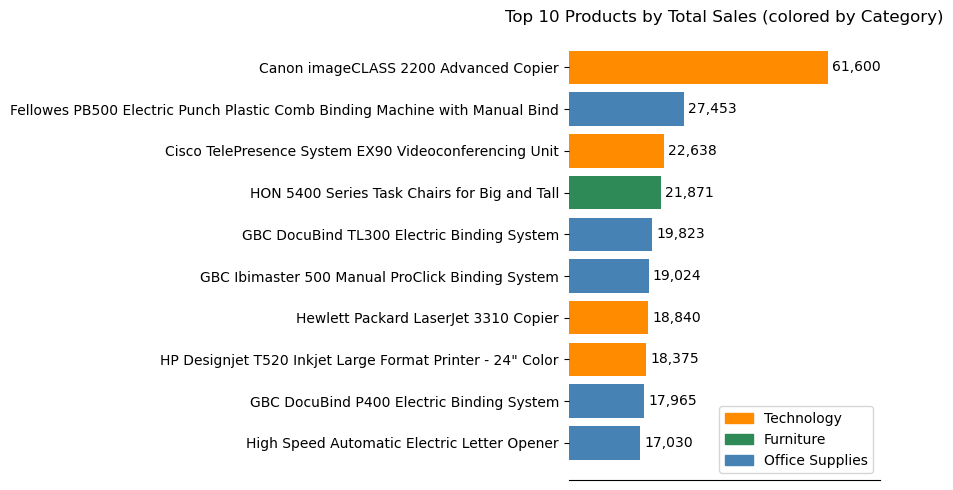

In [120]:
## which Products (by category) contribute the most sales

top_products = sup_store.groupby(['Product Name','Category'], observed=True)['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

color_map = {'Technology':'darkorange', 'Furniture':'seagreen', 'Office Supplies':'steelblue'}
colors = top_products['Category'].map(color_map)

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(top_products['Product Name'][::-1], top_products['Sales'][::-1], color=colors[::-1])
ax.set_title('Top 10 Products by Total Sales (colored by Category)')
ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=3)
ax.spines[['top','right','left']].set_visible(False)
ax.set_xticks([])
ax.margins(x=0.2)

from matplotlib.patches import Patch
legend_elems = [Patch(color=c, label=cat) for cat, c in color_map.items()]
ax.legend(handles=legend_elems, loc='lower right')
plt.tight_layout()
plt.show()

In [121]:
## Number of Orders (count) made in each Category

category_summary = sup_store.groupby('Category', observed=True)['Sales'].agg(['sum','mean','count']).sort_values('sum', ascending=False)
print(category_summary)

                         sum        mean  count
Category                                       
Technology       827455.8730  456.401474   1813
Furniture        728658.5757  350.653790   2078
Office Supplies  705422.3340  119.381001   5909


The Canon imageCLASS 2200 Advanced Copier under the Technology Category is most sold product (~ USD 62K).  
The top-selling products list is dominated by expensive, big-ticket equipment ,such as copiers, binding systems, and printers, rather than the everyday low-cost office items. This pattern spans both the Technology and Office Supplies categories, showing that it's less about which category a product belongs to, and more about whether it's a large occasional purchase versus a small routine one. Technology with the smallest order (1813) had one of it's product being the most sold product.

### RQ2: What factors have the greatest influence on product demand across different regions and product categories?

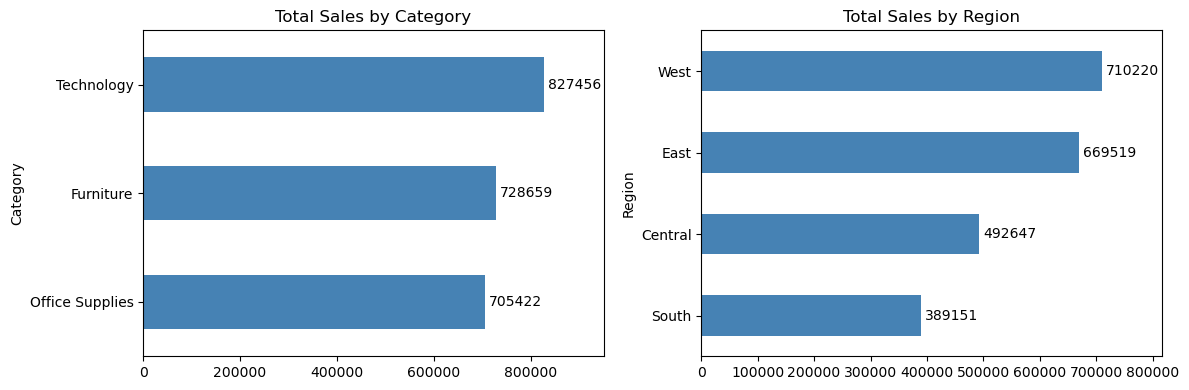

Category: p=0.0000 -> significant
Region: p=0.0000 -> significant


In [122]:
# RQ2: What factors have the greatest influence on product demand across different regions and product categories?

from scipy.stats import kruskal

# Total sales by Category / Region
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, col in zip(axes, ['Category','Region']):
    data = sup_store.groupby(col, observed=True)['Sales'].sum().sort_values()
    data.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Total Sales by {col}')
    ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
    ax.margins(x=0.15)
plt.tight_layout()
plt.show()

# Statistical significance of each factor
for col in ['Category','Region']:
    groups = [g['Sales'].values for _, g in sup_store.groupby(col, observed=True)]
    stat, p = kruskal(*groups)
    print(f"{col}: p={p:.4f}", "-> significant" if p < 0.05 else "-> not significant")


- Category Trends: Technology leads total sales at USD 827K despite having the fewest orders, while Office Supplies generates far lower revenue overall because individual order values are much smaller.
- Regional Breakdown: Sales drop steadily by region, starting in the West (~ USD 710K), followed by the East (~ USD 670K), Central (~ USD 493K), and South (~ USD 389K).
- A Kruskal-Wallis statistical test confirmed that these differences across both categories and regions are statistically significant (p < 0.05), meaning both Category and Region are genuine, real factors that affect sales.

### RQ3: How does product demand vary by season and time of year?

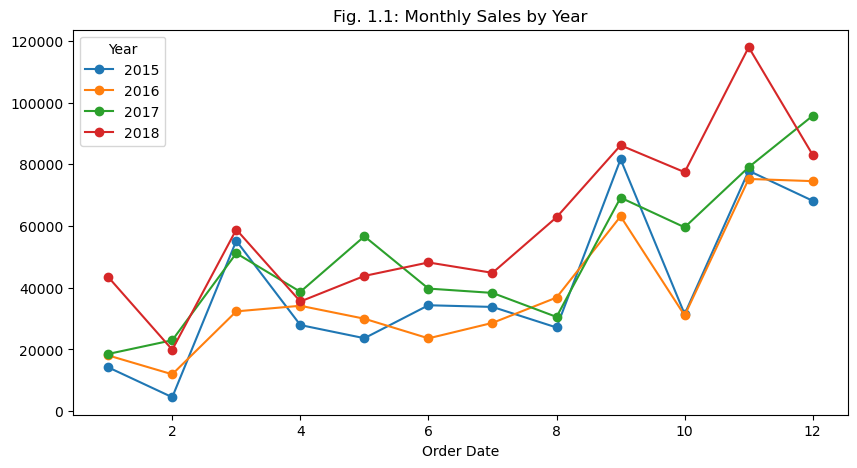

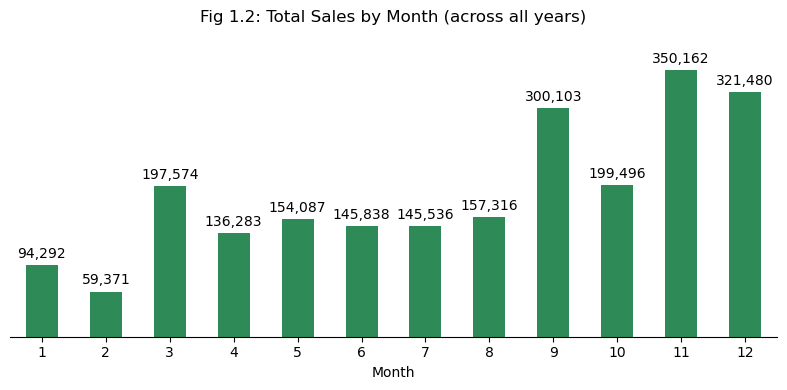

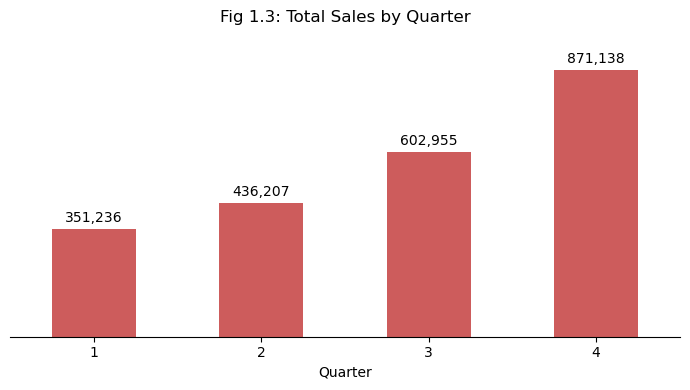

In [123]:
## RQ3: How does product demand vary by season and time of year?

# Yearly 

year_month = sup_store.groupby([sup_store['Order Date'].dt.year, sup_store['Order Date'].dt.month])['Sales'].sum().unstack(0)
year_month.plot(figsize=(10,5), marker='o', title='Fig. 1.1: Monthly Sales by Year')
plt.legend(title='Year')
plt.show()

sup_store['Order Date'] = pd.to_datetime(sup_store['Order Date'], format='mixed', dayfirst=True)
# Adding these columns to the dataset
sup_store['Month'] = sup_store['Order Date'].dt.month
sup_store['Quarter'] = sup_store['Order Date'].dt.quarter

monthly = sup_store.groupby('Month')['Sales'].sum()
quarterly = sup_store.groupby('Quarter')['Sales'].sum()

# Monthly
fig, ax = plt.subplots(figsize=(8,4))
monthly.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Fig 1.2: Total Sales by Month (across all years)')
ax.bar_label(ax.containers[0], fmt=lambda x: f'{x:,.0f}', padding=3, rotation=0)
ax.spines[['top','right','left']].set_visible(False)
ax.set_yticks([])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

# Quarterly
fig, ax = plt.subplots(figsize=(7,4))
quarterly.plot(kind='bar', ax=ax, color='indianred')
ax.set_title('Fig 1.3: Total Sales by Quarter')
ax.bar_label(ax.containers[0], fmt=lambda x: f'{x:,.0f}', padding=3)
ax.spines[['top','right','left']].set_visible(False)
ax.set_yticks([])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

The monthly sales from 2015 to 2018 (Fig 1.1) reveals two clear trends, thus strong annual growth and a predictable quarter 4 (Q4) seasonality.

- Year-Over-Year Growth: 2018 sales outperformed all previous years in almost every month—highlighted by a November peak of ~ USD 118K, up 51% from ~ USD 78K in 2015.

- Holiday Seasonality: November and December consistently deliver peak sales every single year, aligning with standard US retail holiday activity (e.g., Black Friday, Cyber Monday, Christmas). While this Q4 surge aligns with retail holiday trends, the dataset lacks explicit holiday flags to confirm direct causality.

### RQ4. How does sales variability differ between Region-level and State-level data?

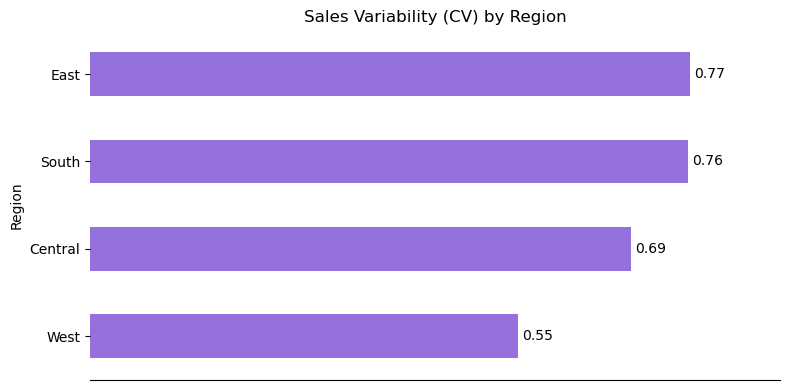

In [124]:
#RQ4. How does sales variability differ between Region-level and State-level data?

# Coefficient of Variation (CV) = std / mean — a standardized measure of
# how inconsistent monthly sales are, regardless of the area's size.
# Higher CV = less predictable/consistent sales pattern.

region_monthly = sup_store.groupby(['Region', sup_store['Order Date'].dt.to_period('M')], observed=True)['Sales'].sum().reset_index()
region_monthly.columns = ['Region','Month','Sales']
region_cv = region_monthly.groupby('Region', observed=True)['Sales'].agg(['mean','std'])
region_cv['CV'] = region_cv['std'] / region_cv['mean']
region_cv = region_cv.sort_values('CV')

top_states = sup_store['State'].value_counts().head(5).index.tolist()
state_monthly = sup_store.groupby(['State', sup_store['Order Date'].dt.to_period('M')], observed=True)['Sales'].sum().reset_index()
state_monthly.columns = ['State','Month','Sales']
state_cv = state_monthly[state_monthly['State'].isin(top_states)].groupby('State', observed=True)['Sales'].agg(['mean','std'])
state_cv['CV'] = state_cv['std'] / state_cv['mean']
state_cv = state_cv.sort_values('CV')

# Region chart
fig, ax = plt.subplots(figsize=(8,4))
region_cv['CV'].plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_title('Sales Variability (CV) by Region')
ax.bar_label(ax.containers[0], fmt=lambda x: f'{x:.2f}', padding=3)
ax.spines[['top','right','left']].set_visible(False)
ax.set_xticks([])
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

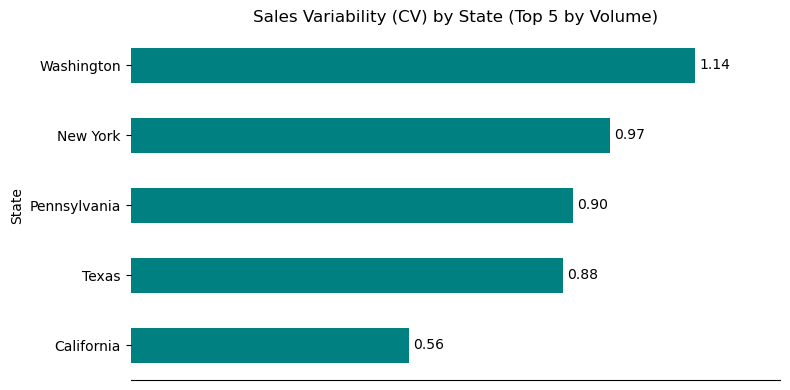

In [125]:
# State chart
fig, ax = plt.subplots(figsize=(8,4))
state_cv['CV'].plot(kind='barh', ax=ax, color='teal')
ax.set_title('Sales Variability (CV) by State (Top 5 by Volume)')
ax.bar_label(ax.containers[0], fmt=lambda x: f'{x:.2f}', padding=3)
ax.spines[['top','right','left']].set_visible(False)
ax.set_xticks([])
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

- To test whether combining states into a broader Region makes sales patterns more stable and predictable, the **Coefficient of Variation (CV)** was calculated to measure how much monthly sales goes up and down relative to its own average for each Region, and separately for the top 5 States by order volume. **A higher CV means less consistent and more unpredictable sales**.

- The results show that being part of a bigger Region does not automatically make sales more consistent. **West is the most stable Region (CV ≈ 0.55)**, but **California (a single state) is just as stable on its own (CV ≈ 0.56)**, nearly matching an entire multi-state region.

- At the other end, **Washington (also a single state with CV ≈ 1.14)** is the least consistent area in either group, more volatile than even the worst performing Region.

- This suggests that how predictable an area's sales are depends on the specific place itself, not on how many states are grouped together into it. Aggregating to Region level is not, by itself, a reliable way to get smoother or more stable demand data.


## Machine Learning


### RQ5. Which forecasting or machine learning approach provides the most accurate demand predictions?

The goal for this model is to predicting a continuous number (in this dataset, the column Sales), to help predict questions "how much will sales be for next month?

In [126]:
# monthly total sales
monthly = sup_store.groupby(sup_store['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly.index = monthly.index.to_timestamp()
monthly = monthly.asfreq('MS')

# target variable = Sales
# feature variable: trend, month, lags, rolling average
feat = monthly.reset_index()
feat.columns = ['Month','Sales']
feat['t'] = np.arange(len(feat))
feat['month_num'] = feat['Month'].dt.month
feat['lag_1'] = feat['Sales'].shift(1)
feat['lag_12'] = feat['Sales'].shift(12)
feat['rolling_3'] = feat['Sales'].shift(1).rolling(3).mean()
feat = feat.dropna().reset_index(drop=True)

# 80/20 chronological split 
split_idx = int(len(feat) * 0.8)
train_f, test_f = feat.iloc[:split_idx], feat.iloc[split_idx:]
print(f"Training on {len(train_f)} months, testing on {len(test_f)} months")

feat_cols = ['t','month_num','lag_1','lag_12','rolling_3']
results = {}

# MAE (Mean Absolute Error): the average amount the model's prediction was off by, in either direction
# MAPE (Mean Absolute Percentage Error): the average error expressed as a percentage of the actual value
# RMSE (Root Mean Squared Error): similar to MAE, but squares the errors before averaging. 


## LINEAR REGRESSION MODEL
lr = LinearRegression().fit(train_f[feat_cols], train_f['Sales'])
preds_lr = lr.predict(test_f[feat_cols])
results['Linear Regression'] = {
    'MAE': mean_absolute_error(test_f['Sales'], preds_lr),
    'RMSE': np.sqrt(mean_squared_error(test_f['Sales'], preds_lr)),
    'MAPE': mean_absolute_percentage_error(test_f['Sales'], preds_lr)
}


# RANDOM FOREST REGRESSION
ran_f = RandomForestRegressor(n_estimators=300, random_state=42).fit(train_f[feat_cols], train_f['Sales'])
preds_ran_f = ran_f.predict(test_f[feat_cols])
results['Random Forest'] = {
    'MAE': mean_absolute_error(test_f['Sales'], preds_ran_f),
    'RMSE': np.sqrt(mean_squared_error(test_f['Sales'], preds_ran_f)),
    'MAPE': mean_absolute_percentage_error(test_f['Sales'], preds_ran_f)
}


results_df = pd.DataFrame(results).T
results_df['MAPE'] = (results_df['MAPE'] * 100).round(1)
results_df[['MAE','RMSE']] = results_df[['MAE','RMSE']].round(0)
print(results_df)

Training on 28 months, testing on 8 months
                       MAE     RMSE  MAPE
Linear Regression  12771.0  15454.0  18.9
Random Forest      12590.0  15714.0  17.9


### Linear Regression & Random Forest Summary

- Two models were compared to predict future monthly sales. The models were Linear Regression and Random Forest. 

- Both were trained on the same features using 80% of the available months (28 months) for training and the remaining 20% (8 months) held back to test accuracy. The same identical features were a time trend, seasonality indicators, lag features (1-month and 12-month sales), and a 3-month rolling average

- On the held-out test months, Random Forest slightly outperformed Linear Regression on two of the three accuracy measures: it was off by an average of about **USD 12,590** per month **(MAE)** compared to Linear Regression's **USD 12,771**, and had a lower average percentage error of **17.9%** **(MAPE)** versus **18.9%**. Linear Regression was marginally better only on **RMSE**, a metric that weighs large errors more heavily.

- **Random Forest** is selected due to its edge in MAE and MAPE (the most intuitive operational metrics) for forecasting future demand. However, given the limited sample size (28 training months), performance between the two models remains closely matched.

In [127]:
print(feat.shape)
feat.head()

(36, 7)


,Month,Sales,t,month_num,lag_1,lag_12,rolling_3
0,2016-01-01,18066.9576,12,1,68167.0585,14205.707,59176.037400
1,2016-02-01,11951.4110,13,2,18066.9576,4519.892,54713.892267
2,2016-03-01,32339.3184,14,3,11951.4110,55205.797,32728.475700
3,2016-04-01,34154.4685,15,4,32339.3184,27906.855,20785.895667
4,2016-05-01,29959.5305,16,5,34154.4685,23644.303,26148.399300


### Future Prediction
Predicting sales for the next 3 months (January to March 2019) as the last data in the dataset is December 2018

In [128]:
# retrain on ALL available data
final_model = RandomForestRegressor(n_estimators=300, random_state=42)
final_model.fit(feat[feat_cols], feat['Sales'])

# going to predict one month at a time, by feeding each prediction back in as the "known" history for the next month's lag features
history = monthly.copy()
n_future = 3
future_preds = []

for i in range(n_future):
    next_t = len(feat) + i
    next_month_date = history.index[-1] + pd.DateOffset(months=1)
    next_month_num = next_month_date.month
    lag_1 = history.iloc[-1]
    lag_12 = history.iloc[-12]
    rolling_3 = history.iloc[-3:].mean()

    X_next = pd.DataFrame([[next_t, next_month_num, lag_1, lag_12, rolling_3]], columns=feat_cols)
    pred = final_model.predict(X_next)[0]
    future_preds.append((next_month_date, pred))
    history.loc[next_month_date] = pred

future_df = pd.DataFrame(future_preds, columns=['Month','Predicted Sales']).round(2)
print(future_df)

       Month  Predicted Sales
0 2019-01-01         41002.09
1 2019-02-01         29690.98
2 2019-03-01         61943.09


Using the better-performing model (Random Forest), retrained on all available historical data rather than just the 80% training split, the following months were forecast — predicting three months beyond the dataset's final recorded month (December 2018):

### Conclusion

The Demand in this dataset is shaped by **what is being sold and when, more than by broad geography alone**. 

Category and seasonality are the most reliable, consistent drivers of demand, while geographic aggregation (Region vs. State) doesn't meaningfully improve prediction on its own. What matters is the specific area's own sales behavior. 

A relatively simple, well-featured forecasting model **(Random Forest with lag and seasonal features)** can predict monthly demand with real accuracy, achieving under 18% average error even with a limited amount of historical data.

Analysis Prepared by Jessie Nana Adwoa Prah